# SAR-Assisted Land-Cover Understanding under Degraded Optical Conditions

**Case study:** investigate whether Sentinel-1 SAR provides useful information when Sentinel-2
optical observations are partially unavailable (cloud-obscured).

## Problem formulation

Multi-label land-cover classification on paired Sentinel-1/Sentinel-2 patches from
**BigEarthNet v2.0 (reBEN)**, evaluated under three conditions (A: clean optical,
B: degraded optical, C: degraded optical + SAR) at six simulated cloud-coverage levels.

Five models, all trained with the identical regime and seed:

| Model | Input | Architecture | Purpose |
|---|---|---|---|
| **A** | clean S2 | SimpleCNN (12ch) | minimum baseline; evaluated under masks it never saw |
| **B** | masked S2 | SimpleCNN (12ch) + mask augmentation | fair degraded-optical reference |
| **C** | masked S2 ⊕ S1 | SimpleCNN (14ch), **early fusion** (channel concat) | simplest SAR-assisted approach |
| **D** | masked S2 ⊕ S1 | **late fusion**: separate S2/S1 encoders, features concatenated | lets SAR features specialise |
| **E** | masked S2 ⊕ S1 | **deep late fusion**: ResNet18-style S2 encoder + half-width S1 encoder | higher-capacity considered model |

The scientific comparison is **B vs {C, D, E}** with *pixel-identical* deterministic evaluation
masks; **paired bootstrap confidence intervals** quantify which gaps are significant.

## Dataset (external resources — documented per instructions)

- [`hackelle/BigEarthNetV2-Lithuania-Summer-LMDB`](https://huggingface.co/datasets/hackelle/BigEarthNetV2-Lithuania-Summer-LMDB) —
  an LMDB conversion of the official **BigEarthNet v2.0 (reBEN)** subset (Lithuania, summer
  acquisitions), published by a member of the original BigEarthNet team (TU Berlin RSiM).
  8,775 paired S1/S2 patches (~2.5 GB), official train/validation/test splits, 19-class label set.
- Original dataset: Clasen et al., *"reBEN: Refined BigEarthNet Dataset for Remote Sensing Image Analysis"*, 2024.
- Libraries: PyTorch, numpy, pandas, scikit-learn, scipy, matplotlib, lmdb, safetensors, huggingface_hub.
- No pretrained weights are used; all models are trained from scratch in this notebook.

**Known limitations of this subset (discussed at the end):** single country and season →
reduced class diversity; BigEarthNet labels are scene-level (multi-label, from CORINE 2018) and
inherently noisy; simulated masks are an approximation of real cloud cover.


## 1. Setup

Reproducibility: one global seed controls Python/NumPy/PyTorch and every mask we generate.
Evaluation masks are additionally derived from *per-patch* seeds so they are identical across
models and across notebook re-runs.


In [1]:
import json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import ndimage
from sklearn.metrics import f1_score, average_precision_score
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU')

DATA_DIR = Path('data/BENv2_lithuania_summer')
PROC_DIR = Path('data/processed'); PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR  = Path('figures');        FIG_DIR.mkdir(exist_ok=True)

PATCH = 120                       # patch size (pixels) after upsampling all bands to 10 m grid
S2_BANDS = ['B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12']
S1_BANDS = ['VV','VH']

# Simulated cloud-coverage levels used for evaluation (1.0 = optical fully lost -> SAR only)
MASK_LEVELS = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]

# Training hyperparameters (deliberately not tuned, per the case-study instructions)
EPOCHS, BATCH, LR, WD = 30, 64, 1e-3, 1e-4
FORCE_RETRAIN = False             # True -> ignore saved checkpoints and retrain everything
N_BOOT = 1000                     # bootstrap resamples for confidence intervals


C:\Users\varun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Data acquisition

Downloads the LMDB + metadata (~2.5 GB) from HuggingFace. Idempotent — skipped if files exist.


In [2]:
from huggingface_hub import snapshot_download

snapshot_download(repo_id='hackelle/BigEarthNetV2-Lithuania-Summer-LMDB',
                  repo_type='dataset', local_dir=DATA_DIR)

LMDB_PATH = DATA_DIR / 'BENv2_lithuania_summer.lmdb'
META_PATH = DATA_DIR / 'metadata_lithuania_summer.parquet'
for p in [LMDB_PATH, META_PATH]:
    assert p.exists(), f'missing {p}'
print('download OK:', sum(f.stat().st_size for f in DATA_DIR.rglob("*") if f.is_file()) / 1e9, 'GB')


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 180.32it/s]

download OK: 2.482130577 GB


## 3. Data inspection & cleaning

Before modelling: understand splits, label structure, and verify the data is what we think it is.
Patches flagged `contains_cloud_or_shadow` or `contains_seasonal_snow` would confound our
*controlled* degradation experiment — we check and drop them (this subset ships with zero, i.e.
the optical patches are clean, which is exactly what we want as the "clean optical" reference).


(8775, 8)
['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name', 'contains_seasonal_snow', 'contains_cloud_or_shadow']


,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
39329,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_54,S2A_MSIL2A_20170720T100031_61_54,False,False
39330,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_55,S2A_MSIL2A_20170720T100031_61_55,False,False
39331,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_56,S2A_MSIL2A_20170720T100031_61_56,False,False



split counts:
split
train         4206
validation    2418
test          2151
Name: count, dtype: int64

naturally cloudy patches: 0 | snowy: 0


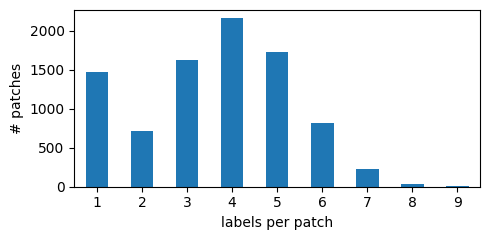

labels
Complex cultivation patterns                                                              4449
Mixed forest                                                                              4174
Coniferous forest                                                                         3862
Arable land                                                                               3738
Land principally occupied by agriculture, with significant areas of natural vegetation    3372
Pastures                                                                                  2981
Transitional woodland, shrub                                                              2588
Broad-leaved forest                                                                       1923
Marine waters                                                                             1432
Urban fabric                                                                              1270
Inland waters                              

In [3]:
meta = pd.read_parquet(META_PATH)
print(meta.shape); print(meta.columns.tolist())
display(meta.head(3))

print('\nsplit counts:'); print(meta['split'].value_counts())
print('\nnaturally cloudy patches:', int(meta['contains_cloud_or_shadow'].sum()),
      '| snowy:', int(meta['contains_seasonal_snow'].sum()))
meta = meta[~meta['contains_cloud_or_shadow'] & ~meta['contains_seasonal_snow']].reset_index(drop=True)

meta['n_labels'] = meta['labels'].apply(len)
ax = meta['n_labels'].value_counts().sort_index().plot.bar(figsize=(5,2.5), rot=0)
ax.set_xlabel('labels per patch'); ax.set_ylabel('# patches'); plt.tight_layout(); plt.show()

freq = meta.explode('labels')['labels'].value_counts()
print(freq.to_string())


### Label space

Patches carry 1–9 of the 19 BigEarthNet classes (median ≈ 4) → this is a **multi-label**
problem. We keep the **11 classes with ≥ 1,000 positive patches**; the remaining 6 rare classes
(< 350 patches, some < 100) cannot be learned or evaluated reliably from this subset and are
dropped from the label space. Patches are kept as long as they have ≥ 1 positive among the 11.


In [4]:
CLASSES = [
    'Urban fabric',
    'Arable land',
    'Pastures',
    'Complex cultivation patterns',
    'Land principally occupied by agriculture, with significant areas of natural vegetation',
    'Broad-leaved forest',
    'Coniferous forest',
    'Mixed forest',
    'Transitional woodland, shrub',
    'Inland waters',
    'Marine waters',
]
NC = len(CLASSES)
assert set(CLASSES) == set(freq[freq >= 1000].index), 'class list out of sync with data'

def to_multihot(labels):
    v = np.zeros(NC, dtype=np.float32)
    for l in labels:
        if l in CLASSES: v[CLASSES.index(l)] = 1.0
    return v

meta['y'] = meta['labels'].apply(to_multihot)
kept = meta['y'].apply(lambda v: v.sum() > 0)
print(f'dropping {int((~kept).sum())} patches with no positive label among the {NC} classes')
meta = meta[kept].reset_index(drop=True)

# per-split positive counts per class — check every class is represented everywhere
Y = np.stack(meta['y'])
tab = pd.DataFrame({s: Y[(meta['split'] == s).values].sum(0).astype(int)
                    for s in ['train', 'validation', 'test']}, index=CLASSES)
display(tab)
assert (tab > 20).all().all(), 'a class has too little support in some split'


dropping 1 patches with no positive label among the 11 classes


,train,validation,test
Urban fabric,620,385,265
Arable land,1714,1141,883
Pastures,1169,896,916
Complex cultivation patterns,1955,1322,1172
"Land principally occupied by agriculture, with significant areas of natural vegetation",1474,902,996
Broad-leaved forest,905,507,511
Coniferous forest,1782,887,1193
Mixed forest,1851,1109,1214
"Transitional woodland, shrub",1118,585,885
Inland waters,493,265,379


### Probing the LMDB — verify shapes, dtypes, value ranges

Sentinel-2 bands are stored at native resolution (10 m → 120², 20 m → 60², 60 m → 20²) as
reflectance `uint16`; Sentinel-1 as backscatter in dB (negative floats — log-scale power
ratios). We verify rather than assume.


In [5]:
import lmdb
from safetensors.numpy import load as st_load

env = lmdb.open(str(LMDB_PATH), readonly=True, lock=False, readahead=True, subdir=LMDB_PATH.is_dir())

with env.begin() as txn:
    row = meta.iloc[0]
    s2 = st_load(bytes(txn.get(row['patch_id'].encode())))
    s1 = st_load(bytes(txn.get(row['s1_name'].encode())))

for k in sorted(s2): print(f'S2 {k}: {s2[k].shape} {s2[k].dtype}  range [{s2[k].min()}, {s2[k].max()}]')
for k in sorted(s1): print(f'S1 {k}: {s1[k].shape} {s1[k].dtype}  range [{s1[k].min():.2f}, {s1[k].max():.2f}]')


S2 B01: (20, 20) uint16  range [255, 281]
S2 B02: (120, 120) uint16  range [171, 296]
S2 B03: (120, 120) uint16  range [210, 311]
S2 B04: (120, 120) uint16  range [94, 182]
S2 B05: (60, 60) uint16  range [87, 151]
S2 B06: (60, 60) uint16  range [57, 113]
S2 B07: (60, 60) uint16  range [49, 109]
S2 B08: (120, 120) uint16  range [45, 125]
S2 B09: (20, 20) uint16  range [40, 82]
S2 B11: (60, 60) uint16  range [27, 67]
S2 B12: (60, 60) uint16  range [14, 63]
S2 B8A: (60, 60) uint16  range [36, 98]
S1 VH: (120, 120) float32  range [-43.09, -20.47]
S1 VV: (120, 120) float32  range [-28.59, -11.23]


## 4. Preprocessing → memory-mapped arrays

One pass over the LMDB: upsample every band bilinearly to the 10 m grid (120×120), stack into
canonical order, store as `float16` memmaps (`X_opt [N,12,120,120]`, `X_sar [N,2,120,120]`).
~3.5 GB on disk, read back lazily; re-runs of the notebook skip this cell's work entirely.


In [6]:
X_OPT_P, X_SAR_P, IDX_P = PROC_DIR/'X_opt.npy', PROC_DIR/'X_sar.npy', PROC_DIR/'index.parquet'

def resample_to_patch(arr):
    t = torch.from_numpy(arr.astype(np.float32))[None, None]
    if t.shape[-1] != PATCH:
        t = F.interpolate(t, size=(PATCH, PATCH), mode='bilinear', align_corners=False)
    return t[0, 0].numpy()

if not (X_OPT_P.exists() and X_SAR_P.exists() and IDX_P.exists()):
    N = len(meta)
    X_opt = np.lib.format.open_memmap(X_OPT_P, mode='w+', dtype=np.float16, shape=(N, 12, PATCH, PATCH))
    X_sar = np.lib.format.open_memmap(X_SAR_P, mode='w+', dtype=np.float16, shape=(N, 2, PATCH, PATCH))
    with env.begin() as txn:
        for i, row in enumerate(tqdm(meta.itertuples(), total=N, desc='LMDB -> memmap')):
            s2 = st_load(bytes(txn.get(row.patch_id.encode())))
            s1 = st_load(bytes(txn.get(row.s1_name.encode())))
            X_opt[i] = np.stack([resample_to_patch(s2[b]) for b in S2_BANDS]).astype(np.float16)
            X_sar[i] = np.stack([resample_to_patch(s1[b]) for b in S1_BANDS]).astype(np.float16)
    X_opt.flush(); X_sar.flush()
    meta.drop(columns=['y']).to_parquet(IDX_P)   # y rebuilt from labels on load

X_opt = np.load(X_OPT_P, mmap_mode='r')
X_sar = np.load(X_SAR_P, mmap_mode='r')
idx_df = pd.read_parquet(IDX_P)
assert len(idx_df) == len(meta) and (idx_df['patch_id'].values == meta['patch_id'].values).all(), \
    'processed cache out of sync with metadata filter — delete data/processed and re-run'
print('X_opt', X_opt.shape, X_opt.dtype, '| X_sar', X_sar.shape, X_sar.dtype)

split_idx = {s: np.where((meta['split'] == s).values)[0] for s in ['train', 'validation', 'test']}
Y = np.stack(meta['y']).astype(np.float32)
print({k: len(v) for k, v in split_idx.items()})


X_opt (8774, 12, 120, 120) float16 | X_sar (8774, 2, 120, 120) float16
{'train': 4205, 'validation': 2418, 'test': 2151}


### Normalisation statistics (train split only — no leakage)

Per-band mean/std computed on the training split. Inputs are standardised; **masked pixels are
set to 0 after standardisation**, i.e. to the per-band mean — the least-informative value.
SAR backscatter is log-scaled dB; we standardise it with its own stats.


In [7]:
STATS_P = PROC_DIR / 'norm_stats.json'
if not STATS_P.exists():
    tr = split_idx['train']
    sample = tr[::3]                                   # every 3rd train patch is plenty for stats
    xo = X_opt[sample].astype(np.float32)
    xs = X_sar[sample].astype(np.float32)
    stats = {'opt_mean': xo.mean(axis=(0, 2, 3)).tolist(), 'opt_std': xo.std(axis=(0, 2, 3)).tolist(),
             'sar_mean': xs.mean(axis=(0, 2, 3)).tolist(), 'sar_std': xs.std(axis=(0, 2, 3)).tolist()}
    STATS_P.write_text(json.dumps(stats, indent=2)); del xo, xs
stats = json.loads(STATS_P.read_text())
OPT_MEAN = torch.tensor(stats['opt_mean']).view(1, 12, 1, 1)
OPT_STD  = torch.tensor(stats['opt_std']).view(1, 12, 1, 1)
SAR_MEAN = torch.tensor(stats['sar_mean']).view(1, 2, 1, 1)
SAR_STD  = torch.tensor(stats['sar_std']).view(1, 2, 1, 1)
pd.DataFrame({'band': S2_BANDS + S1_BANDS,
              'mean': stats['opt_mean'] + stats['sar_mean'],
              'std':  stats['opt_std'] + stats['sar_std']}).round(1)


,band,mean,std
0,B01,232.3,140.9
1,B02,306.5,192.0
2,B03,479.9,254.2
3,B04,372.7,330.9
4,B05,732.2,435.9
5,B06,1755.1,996.2
6,B07,2107.8,1214.4
7,B08,2268.5,1351.3
8,B8A,2304.7,1331.2
9,B09,2302.4,1290.1


### Visual sanity check — RGB composites and SAR


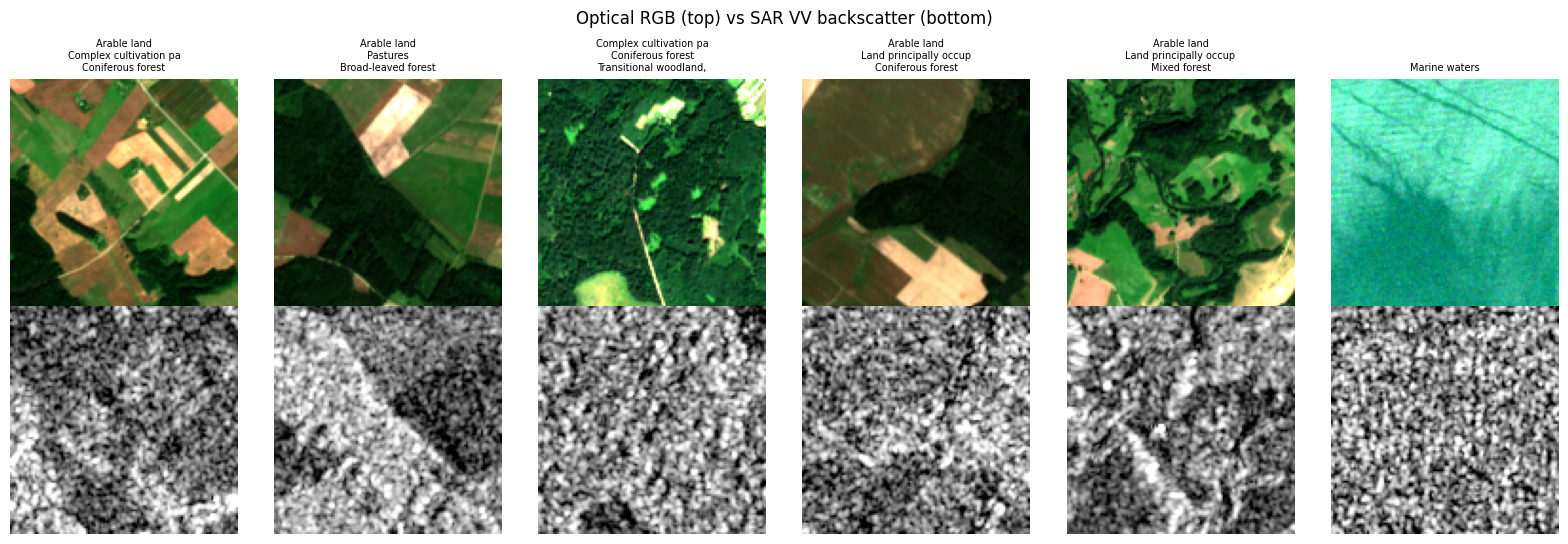

In [8]:
def rgb(i):
    x = X_opt[i, [3, 2, 1]].astype(np.float32)         # B04,B03,B02
    lo, hi = np.percentile(x, 2), np.percentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1).transpose(1, 2, 0)

def sar_img(i, ch=0):
    x = X_sar[i, ch].astype(np.float32)
    lo, hi = np.percentile(x, 2), np.percentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)

rng = np.random.default_rng(SEED)
show = rng.choice(split_idx['train'], 6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
for j, i in enumerate(show):
    axes[0, j].imshow(rgb(i)); axes[1, j].imshow(sar_img(i), cmap='gray')
    labs = [c for c, v in zip(CLASSES, Y[i]) if v]
    axes[0, j].set_title('\n'.join(l[:22] for l in labs[:3]), fontsize=7)
    for ax in axes[:, j]: ax.axis('off')
plt.suptitle('Optical RGB (top) vs SAR VV backscatter (bottom)'); plt.tight_layout()
plt.savefig(FIG_DIR / 'samples.png', dpi=120); plt.show()


## 5. Simulated cloud masking

Real clouds are spatially-correlated blobs, not random pixels. We threshold smoothed Gaussian
noise (spline-upsampled 8×8 → 120×120) at the quantile matching the requested coverage —
giving natural-looking cumulus-like shapes with *exact* coverage control.

- **Evaluation masks are deterministic**: seeded by `(SEED, coverage-level, patch-index)`, so
  every model at every re-run sees pixel-identical degradation → paired comparison.
- **Training masks are random**: each batch draws fresh masks with random coverage
  (50% chance clean, otherwise coverage ~ U(0.1, 0.95)) — mask augmentation.
- Masked pixels → 0 after standardisation (= per-band mean). The model receives no explicit
  mask channel in this version (discussed in §10).


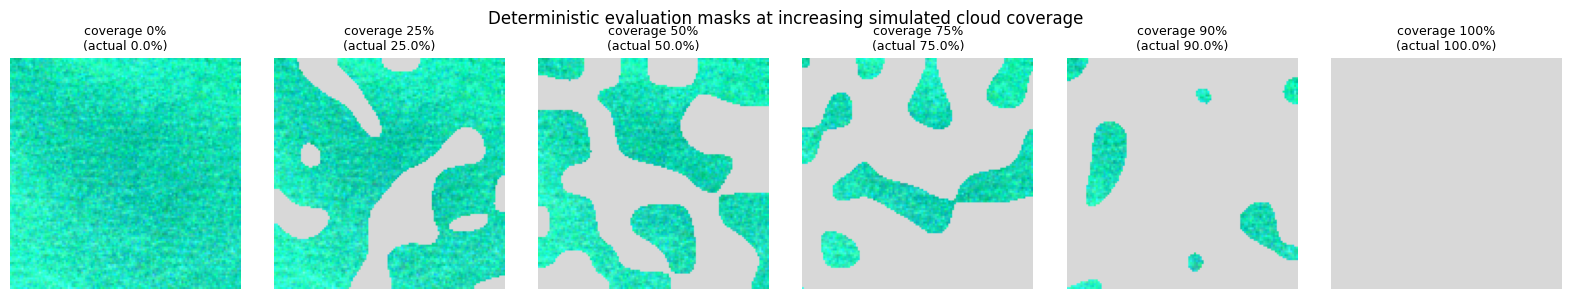

In [9]:
def cloud_mask(coverage, rng, size=PATCH, cells=8):
    if coverage <= 0: return np.zeros((size, size), bool)
    if coverage >= 1: return np.ones((size, size), bool)
    noise = ndimage.zoom(rng.standard_normal((cells, cells)), size / cells, order=3)
    return noise >= np.quantile(noise, 1 - coverage)

def eval_mask(level_i, patch_i):
    return cloud_mask(MASK_LEVELS[level_i], np.random.default_rng((SEED, level_i, int(patch_i))))

i = split_idx['test'][0]
fig, axes = plt.subplots(1, len(MASK_LEVELS), figsize=(16, 3))
for li, ax in enumerate(axes):
    m = eval_mask(li, i)
    im = rgb(i).copy(); im[m] = 0.85
    ax.imshow(im); ax.set_title(f'coverage {MASK_LEVELS[li]:.0%}\n(actual {m.mean():.1%})', fontsize=9)
    ax.axis('off')
plt.suptitle('Deterministic evaluation masks at increasing simulated cloud coverage')
plt.tight_layout(); plt.savefig(FIG_DIR / 'masks.png', dpi=120); plt.show()


## 6. Batching & degradation pipeline

Simple main-process batching straight from the memmaps (Windows-friendly; the models are small
enough that the GPU, not I/O, is the bottleneck). Standardisation and masking happen per batch.
All fusion models receive one 14-channel tensor; dual-encoder models split it internally.


In [10]:
def make_batch(ids, mask_spec, use_sar, train_rng=None):
    """mask_spec: None=clean | int=eval level index (deterministic) | 'random'=train augmentation."""
    xo = torch.from_numpy(X_opt[ids].astype(np.float32))
    xo = (xo - OPT_MEAN) / OPT_STD
    if mask_spec is not None:
        for j, pi in enumerate(ids):
            if mask_spec == 'random':
                if train_rng.random() < 0.5:
                    continue
                m = cloud_mask(train_rng.uniform(0.1, 0.95), train_rng)
            else:
                m = eval_mask(mask_spec, pi)
            xo[j, :, torch.from_numpy(m)] = 0.0
    if use_sar:
        xs = torch.from_numpy(X_sar[ids].astype(np.float32))
        xs = (xs - SAR_MEAN) / SAR_STD
        xo = torch.cat([xo, xs], 1)                     # SAR is never masked
    return xo

def batches(ids, bs, shuffle=False, rng=None):
    ids = ids.copy()
    if shuffle: rng.shuffle(ids)
    for k in range(0, len(ids), bs):
        yield ids[k:k + bs]


## 7. Models

Three architectures, same output head style (multi-label sigmoid):

1. **SimpleCNN** — four conv blocks (32→64→128→256), GAP, linear. ~1.9 M params.
   Used for A (12ch), B (12ch) and C (14ch early fusion).
2. **DualEncoderCNN (D, late fusion)** — one SimpleCNN trunk per modality; pooled features
   concatenated (256+256) before the head. SAR features can specialise instead of competing
   with 12 optical channels in the first convolution. ~3.8 M params.
3. **DeepDualEncoder (E)** — ResNet18-style residual encoder for optical (width 64) plus a
   half-width (32) one for SAR, late fusion. ~14 M params — the "complicated" model; tests
   whether capacity, depth and residual connections change the SAR story.


In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, in_ch, n_classes=NC):
        super().__init__()
        layers, c = [], in_ch
        for out in [32, 64, 128, 256]:
            layers += [nn.Conv2d(c, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU(inplace=True),
                       nn.Conv2d(out, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU(inplace=True),
                       nn.MaxPool2d(2)]
            c = out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(c, n_classes))
    def forward(self, x): return self.head(self.features(x))


class DualEncoderCNN(nn.Module):
    """Late fusion: separate optical/SAR encoders, pooled features concatenated before the head."""
    def __init__(self, n_classes=NC):
        super().__init__()
        self.opt_enc = SimpleCNN(12).features
        self.sar_enc = SimpleCNN(2).features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256 + 256, n_classes))
    def forward(self, x):
        f = torch.cat([self.pool(self.opt_enc(x[:, :12])), self.pool(self.sar_enc(x[:, 12:]))], 1)
        return self.head(f)


class BasicBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False); self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False);     self.bn2 = nn.BatchNorm2d(cout)
        self.short = (nn.Sequential(nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout))
                      if (stride != 1 or cin != cout) else nn.Identity())
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.short(x))


class ResNetEncoder(nn.Module):
    """ResNet18-style: stem (stride 4 total) + 4 residual stages of 2 blocks."""
    def __init__(self, in_ch, width=64):
        super().__init__()
        w = [width, width * 2, width * 4, width * 8]
        self.stem = nn.Sequential(nn.Conv2d(in_ch, w[0], 3, 2, 1, bias=False), nn.BatchNorm2d(w[0]),
                                  nn.ReLU(inplace=True), nn.MaxPool2d(2))          # 120 -> 30
        stages, c = [], w[0]
        for i, cout in enumerate(w):
            stages += [BasicBlock(c, cout, stride=1 if i == 0 else 2), BasicBlock(cout, cout)]
            c = cout
        self.stages = nn.Sequential(*stages)                                       # 30 -> 30,15,8,4
        self.out_dim = c
    def forward(self, x): return self.stages(self.stem(x))


class DeepDualEncoder(nn.Module):
    """Deep late fusion: ResNet18-style optical encoder + half-width SAR encoder."""
    def __init__(self, n_classes=NC):
        super().__init__()
        self.opt_enc = ResNetEncoder(12, width=64)
        self.sar_enc = ResNetEncoder(2, width=32)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3),
                                  nn.Linear(self.opt_enc.out_dim + self.sar_enc.out_dim, n_classes))
    def forward(self, x):
        f = torch.cat([self.pool(self.opt_enc(x[:, :12])), self.pool(self.sar_enc(x[:, 12:]))], 1)
        return self.head(f)


for cls, ch in [(SimpleCNN, 12), (SimpleCNN, 14), (DualEncoderCNN, None), (DeepDualEncoder, None)]:
    m = cls(ch) if ch else cls()
    print(f'{cls.__name__}({ch or ""}): {sum(p.numel() for p in m.parameters()) / 1e6:.2f} M params')


SimpleCNN(12): 1.18 M params
SimpleCNN(14): 1.18 M params
DualEncoderCNN(): 2.36 M params
DeepDualEncoder(): 13.98 M params


## 8. Training

Five models, identical regime (AdamW, cosine schedule, BCE with class-balancing `pos_weight`,
mixed precision, best-val-macro-F1 checkpointing). Completed models are **loaded from
checkpoint** instead of retrained (set `FORCE_RETRAIN = True` to redo everything).

Validation metric: macro-F1 on the validation split at 50% deterministic coverage for the
mask-trained models (their target regime), clean for A.


In [12]:
pos = Y[split_idx['train']].mean(0)
POS_WEIGHT = torch.tensor(np.clip((1 - pos) / pos, 1.0, 10.0), dtype=torch.float32, device=DEVICE)
display(pd.DataFrame({'class': CLASSES, 'train_pos_rate': pos.round(3),
                      'pos_weight': POS_WEIGHT.cpu().numpy().round(2)}))

@torch.no_grad()
def predict(model, ids, mask_spec, use_sar, bs=256):
    model.eval(); out = []
    for b in batches(ids, bs):
        x = make_batch(b, mask_spec, use_sar).to(DEVICE, non_blocking=True)
        with torch.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            out.append(torch.sigmoid(model(x)).float().cpu())
    return torch.cat(out).numpy()

def macro_f1(y, p, thr=0.5): return f1_score(y, p >= thr, average='macro', zero_division=0)

def train_or_load(name, model_fn, use_sar, mask_train, val_mask_spec, epochs=EPOCHS):
    ckpt, hist_p = PROC_DIR / f'{name}.pt', PROC_DIR / f'{name}_history.csv'
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = model_fn().to(DEVICE)
    if ckpt.exists() and not FORCE_RETRAIN:
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        print(f'[{name}] loaded checkpoint ({ckpt})')
        return model, (pd.read_csv(hist_p) if hist_p.exists() else None)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler(enabled=DEVICE.type == 'cuda')
    crit = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    tr, va = split_idx['train'], split_idx['validation']
    rng = np.random.default_rng(SEED)
    best_f1, best_state, hist = -1, None, []
    for ep in range(epochs):
        model.train(); losses = []; t0 = time.time()
        for b in batches(tr, BATCH, shuffle=True, rng=rng):
            x = make_batch(b, 'random' if mask_train else None, use_sar, train_rng=rng).to(DEVICE)
            yb = torch.from_numpy(Y[b]).to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast('cuda', enabled=DEVICE.type == 'cuda'):
                loss = crit(model(x), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            losses.append(loss.item())
        sched.step()
        vf1 = macro_f1(Y[va], predict(model, va, val_mask_spec, use_sar))
        hist.append({'epoch': ep, 'loss': float(np.mean(losses)), 'val_macro_f1': vf1})
        if vf1 > best_f1: best_f1, best_state = vf1, {k: v.clone() for k, v in model.state_dict().items()}
        print(f'[{name}] ep {ep + 1:02d}/{epochs}  loss {np.mean(losses):.4f}  val mF1 {vf1:.4f}  ({time.time() - t0:.0f}s)')
    model.load_state_dict(best_state)
    pd.DataFrame(hist).to_csv(hist_p, index=False)
    torch.save(model.state_dict(), ckpt)
    print(f'[{name}] best val macro-F1 = {best_f1:.4f}')
    return model, pd.DataFrame(hist)

LEVEL50 = MASK_LEVELS.index(0.5)


,class,train_pos_rate,pos_weight
0,Urban fabric,0.147,5.78
1,Arable land,0.408,1.45
2,Pastures,0.278,2.60
3,Complex cultivation patterns,0.465,1.15
4,"Land principally occupied by agriculture, with...",0.351,1.85
5,Broad-leaved forest,0.215,3.65
6,Coniferous forest,0.424,1.36
7,Mixed forest,0.440,1.27
8,"Transitional woodland, shrub",0.266,2.76
9,Inland waters,0.117,7.53


In [13]:
model_A, hist_A = train_or_load('model_A_optical_clean', lambda: SimpleCNN(12),
                                use_sar=False, mask_train=False, val_mask_spec=None)


[model_A_optical_clean] loaded checkpoint (data\processed\model_A_optical_clean.pt)


In [14]:
model_B, hist_B = train_or_load('model_B_optical_maskaug', lambda: SimpleCNN(12),
                                use_sar=False, mask_train=True, val_mask_spec=LEVEL50)


[model_B_optical_maskaug] loaded checkpoint (data\processed\model_B_optical_maskaug.pt)


In [15]:
model_C, hist_C = train_or_load('model_C_opticalSAR_maskaug', lambda: SimpleCNN(14),
                                use_sar=True, mask_train=True, val_mask_spec=LEVEL50)


[model_C_opticalSAR_maskaug] loaded checkpoint (data\processed\model_C_opticalSAR_maskaug.pt)


In [16]:
model_D, hist_D = train_or_load('model_D_opticalSAR_latefusion', DualEncoderCNN,
                                use_sar=True, mask_train=True, val_mask_spec=LEVEL50)


[model_D_opticalSAR_latefusion] loaded checkpoint (data\processed\model_D_opticalSAR_latefusion.pt)


In [17]:
model_E, hist_E = train_or_load('model_E_deep_latefusion', DeepDualEncoder,
                                use_sar=True, mask_train=True, val_mask_spec=LEVEL50)


[model_E_deep_latefusion] loaded checkpoint (data\processed\model_E_deep_latefusion.pt)


### Training curves

Loss decreases smoothly for all models. Two caveats when reading them: losses are **not
comparable across models** (mask-trained models compute theirs on masked inputs — a harder
objective), and validation metrics differ by design (A validated clean, others at 50%
coverage). The jagged val curve is normal for small CNNs + BatchNorm; we checkpoint the
best-val epoch, not the last.


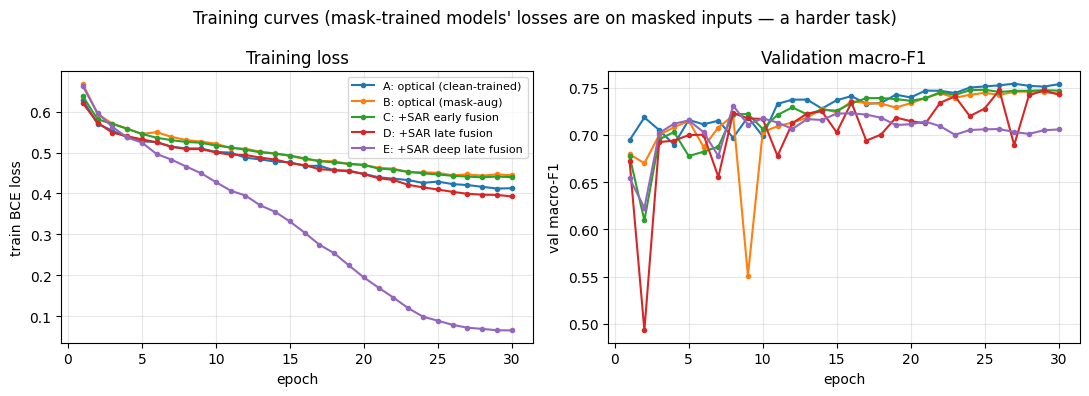

In [18]:
MODEL_FILES = [('model_A_optical_clean', 'A: optical (clean-trained)'),
               ('model_B_optical_maskaug', 'B: optical (mask-aug)'),
               ('model_C_opticalSAR_maskaug', 'C: +SAR early fusion'),
               ('model_D_opticalSAR_latefusion', 'D: +SAR late fusion'),
               ('model_E_deep_latefusion', 'E: +SAR deep late fusion')]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, label in MODEL_FILES:
    p = PROC_DIR / f'{name}_history.csv'
    if not p.exists(): continue
    h = pd.read_csv(p)
    axes[0].plot(h['epoch'] + 1, h['loss'], marker='o', ms=3, label=label)
    axes[1].plot(h['epoch'] + 1, h['val_macro_f1'], marker='o', ms=3, label=label)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train BCE loss'); axes[0].set_title('Training loss')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro-F1'); axes[1].set_title('Validation macro-F1')
for ax in axes: ax.grid(alpha=.3)
axes[0].legend(fontsize=8)
plt.suptitle("Training curves (mask-trained models' losses are on masked inputs — a harder task)")
plt.tight_layout(); plt.savefig(FIG_DIR / 'training_curves.png', dpi=120); plt.show()


## 9. Evaluation — conditions × cloud-coverage levels

Test-split metrics (threshold 0.5, deliberately untuned): **macro-F1** (primary — insensitive to
class imbalance), **mAP** (threshold-free), **micro-F1** and **subset accuracy** (exact match,
the strictest). Every model sees identical masks at each level.


In [19]:
te = split_idx['test']
EVALS = [('A: optical (clean-trained)', model_A, False),
         ('B: optical (mask-aug)',      model_B, False),
         ('C: +SAR early fusion',       model_C, True),
         ('D: +SAR late fusion',        model_D, True),
         ('E: +SAR deep late fusion',   model_E, True)]
results, probs_cache = [], {}
for name, model, use_sar in EVALS:
    for li, lvl in enumerate(tqdm(MASK_LEVELS, desc=name)):
        p = predict(model, te, li if lvl > 0 else None, use_sar)
        probs_cache[(name, lvl)] = p
        results.append({'model': name, 'coverage': lvl,
                        'macro_F1': macro_f1(Y[te], p),
                        'mAP': average_precision_score(Y[te], p, average='macro'),
                        'micro_F1': f1_score(Y[te], p >= 0.5, average='micro', zero_division=0),
                        'subset_acc': float(((p >= 0.5) == Y[te].astype(bool)).all(1).mean())})
res = pd.DataFrame(results)
display(res.pivot(index='coverage', columns='model', values='macro_F1').round(4))
display(res.pivot(index='coverage', columns='model', values='mAP').round(4))
res.to_csv(PROC_DIR / 'results.csv', index=False)


A: optical (clean-trained):   0%|          | 0/6 [00:00<?, ?it/s]

A: optical (clean-trained):  17%|█▋        | 1/6 [00:10<00:53, 10.67s/it]

A: optical (clean-trained):  33%|███▎      | 2/6 [00:25<00:53, 13.36s/it]

A: optical (clean-trained):  50%|█████     | 3/6 [00:39<00:39, 13.32s/it]

A: optical (clean-trained):  67%|██████▋   | 4/6 [00:52<00:26, 13.45s/it]

...

E: +SAR deep late fusion:  83%|████████▎ | 5/6 [00:54<00:11, 11.55s/it]

E: +SAR deep late fusion: 100%|██████████| 6/6 [01:00<00:00,  9.62s/it]

E: +SAR deep late fusion: 100%|██████████| 6/6 [01:00<00:00, 10.00s/it]

model,A: optical (clean-trained),B: optical (mask-aug),C: +SAR early fusion,D: +SAR late fusion,E: +SAR deep late fusion
coverage,,,,,
0.00,0.7528,0.7495,0.7514,0.7507,0.7254
0.25,0.7049,0.7461,0.7485,0.7461,0.7260
0.50,0.6326,0.7465,0.7412,0.7443,0.7257
0.75,0.4116,0.7301,0.7333,0.7350,0.7215
0.90,0.2546,0.7144,0.7229,0.7225,0.7114
1.00,0.1179,0.3295,0.7111,0.6388,0.6010


model,A: optical (clean-trained),B: optical (mask-aug),C: +SAR early fusion,D: +SAR late fusion,E: +SAR deep late fusion
coverage,,,,,
0.00,0.8029,0.8051,0.8029,0.8027,0.7708
0.25,0.7891,0.8026,0.7997,0.8008,0.7697
0.50,0.7319,0.7952,0.7930,0.7976,0.7654
0.75,0.6439,0.7793,0.7805,0.7885,0.7594
0.90,0.5417,0.7530,0.7625,0.7727,0.7474
1.00,0.3605,0.3605,0.7344,0.7077,0.6530


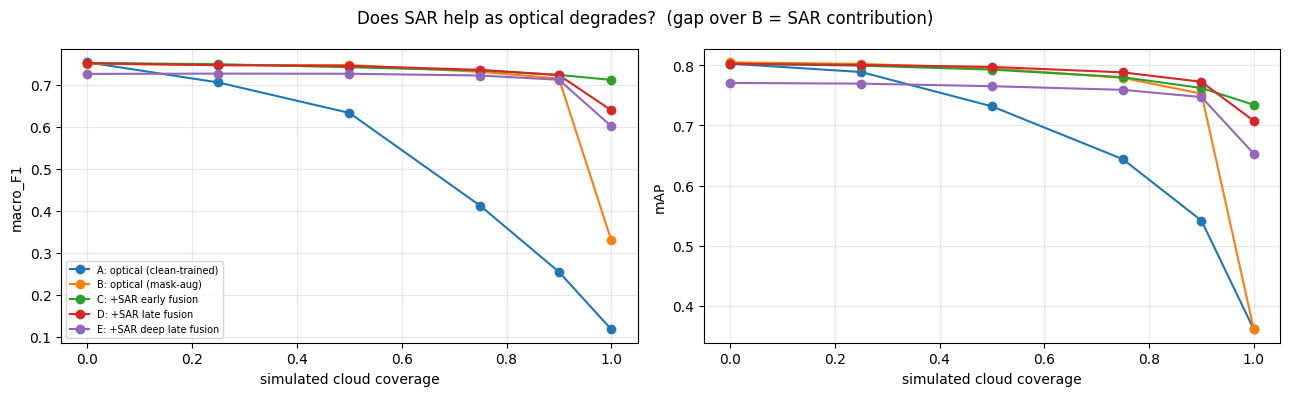

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for metric, ax in zip(['macro_F1', 'mAP'], axes):
    for name, g in res.groupby('model'):
        ax.plot(g['coverage'], g[metric], marker='o', label=name)
    ax.set_xlabel('simulated cloud coverage'); ax.set_ylabel(metric); ax.grid(alpha=.3)
axes[0].legend(fontsize=7)
plt.suptitle('Does SAR help as optical degrades?  (gap over B = SAR contribution)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'coverage_curves.png', dpi=120); plt.show()


### Paired bootstrap confidence intervals

Point metrics hide two noise sources: finite test set and training stochasticity. Here we
quantify the first: resample the 2,151 test patches with replacement 1,000 times and recompute
macro-F1 for every model **on the same resample** (paired). The middle 95% of the resulting
distribution is the CI. For each SAR model we report the paired delta vs model B — if the
delta's CI excludes 0, the gap is significant w.r.t. test-set sampling noise. (Training-seed
variance would require seed replicates — see Discussion.)


In [21]:
BOOT_MODELS = [n for n, _, _ in EVALS if n != 'A: optical (clean-trained)']
rng_b = np.random.default_rng(SEED)
boot_idx = rng_b.integers(0, len(te), size=(N_BOOT, len(te)))   # shared draws -> paired

boot = {}   # (model, coverage) -> np.array of bootstrap macro-F1
yt = Y[te]
for name in tqdm(BOOT_MODELS, desc='bootstrap'):
    for lvl in MASK_LEVELS:
        pred = probs_cache[(name, lvl)] >= 0.5
        boot[(name, lvl)] = np.array([macro_f1(yt[ix], pred[ix]) for ix in boot_idx])

rows = []
for lvl in MASK_LEVELS:
    base = boot[('B: optical (mask-aug)', lvl)]
    for name in BOOT_MODELS:
        s = boot[(name, lvl)]
        row = {'coverage': lvl, 'model': name, 'macro_F1': s.mean(),
               'ci_lo': np.percentile(s, 2.5), 'ci_hi': np.percentile(s, 97.5)}
        if name != 'B: optical (mask-aug)':          # paired delta vs B (undefined for B itself)
            d = s - base
            row.update(delta_vs_B=d.mean(), d_lo=np.percentile(d, 2.5), d_hi=np.percentile(d, 97.5),
                       significant=bool(np.percentile(d, 2.5) > 0 or np.percentile(d, 97.5) < 0))
        rows.append(row)
ci = pd.DataFrame(rows)
display(ci.round(4))
ci.to_csv(PROC_DIR / 'bootstrap_ci.csv', index=False)


bootstrap:   0%|          | 0/4 [00:00<?, ?it/s]

bootstrap:  25%|██▌       | 1/4 [00:43<02:11, 43.71s/it]

bootstrap:  50%|█████     | 2/4 [01:27<01:27, 43.54s/it]

bootstrap:  75%|███████▌  | 3/4 [02:09<00:43, 43.18s/it]

bootstrap: 100%|██████████| 4/4 [02:51<00:00, 42.64s/it]

bootstrap: 100%|██████████| 4/4 [02:51<00:00, 42.93s/it]

,coverage,model,macro_F1,ci_lo,ci_hi,delta_vs_B,d_lo,d_hi,significant
0,0.00,B: optical (mask-aug),0.7495,0.7427,0.7564,NaN,NaN,NaN,NaN
1,0.00,C: +SAR early fusion,0.7514,0.7439,0.7582,0.0018,-0.0028,0.0062,False
2,0.00,D: +SAR late fusion,0.7506,0.7433,0.7578,0.0011,-0.0043,0.0062,False
3,0.00,E: +SAR deep late fusion,0.7254,0.7186,0.7325,-0.0241,-0.0297,-0.0179,True
4,0.25,B: optical (mask-aug),0.7461,0.7390,0.7532,NaN,NaN,NaN,NaN
5,0.25,C: +SAR early fusion,0.7485,0.7417,0.7553,0.0023,-0.0024,0.0068,False
6,0.25,D: +SAR late fusion,0.7461,0.7387,0.7529,0.0000,-0.0052,0.0051,False
7,0.25,E: +SAR deep late fusion,0.7261,0.7189,0.7330,-0.0200,-0.0261,-0.0143,True
8,0.50,B: optical (mask-aug),0.7466,0.7397,0.7539,NaN,NaN,NaN,NaN
9,0.50,C: +SAR early fusion,0.7412,0.7339,0.7480,-0.0054,-0.0107,-0.0004,True


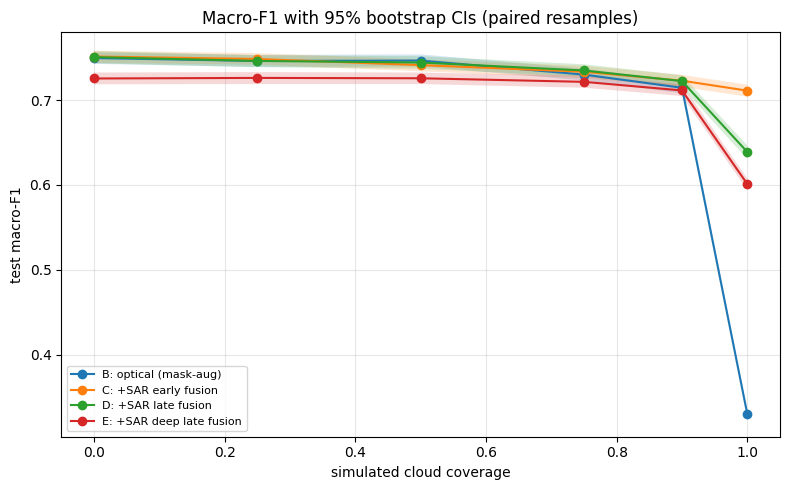

In [22]:
plt.figure(figsize=(8, 5))
for name in BOOT_MODELS:
    g = ci[ci['model'] == name]
    plt.plot(g['coverage'], g['macro_F1'], marker='o', label=name)
    plt.fill_between(g['coverage'], g['ci_lo'], g['ci_hi'], alpha=.18)
plt.xlabel('simulated cloud coverage'); plt.ylabel('test macro-F1')
plt.title('Macro-F1 with 95% bootstrap CIs (paired resamples)')
plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / 'bootstrap_ci.png', dpi=120); plt.show()


### Per-class effect of SAR at heavy degradation (75% coverage)

Per-class F1 deltas of each SAR model vs model B.


,class,F1_B,test_support,dF1_C,dF1_D,dF1_E
3,Complex cultivation patterns,0.810,1172,0.008,-0.021,-0.004
6,Coniferous forest,0.853,1193,-0.018,-0.018,-0.035
7,Mixed forest,0.794,1214,0.009,-0.002,-0.022
2,Pastures,0.720,916,-0.013,-0.001,0.008
1,Arable land,0.749,883,-0.002,-0.000,-0.023
10,Marine waters,1.000,116,0.000,0.000,0.000
4,"Land principally occupied by agriculture, with...",0.724,996,0.010,0.001,0.001
0,Urban fabric,0.499,265,-0.004,0.009,-0.024
5,Broad-leaved forest,0.538,511,-0.000,0.010,-0.043
8,"Transitional woodland, shrub",0.604,885,0.003,0.011,-0.012


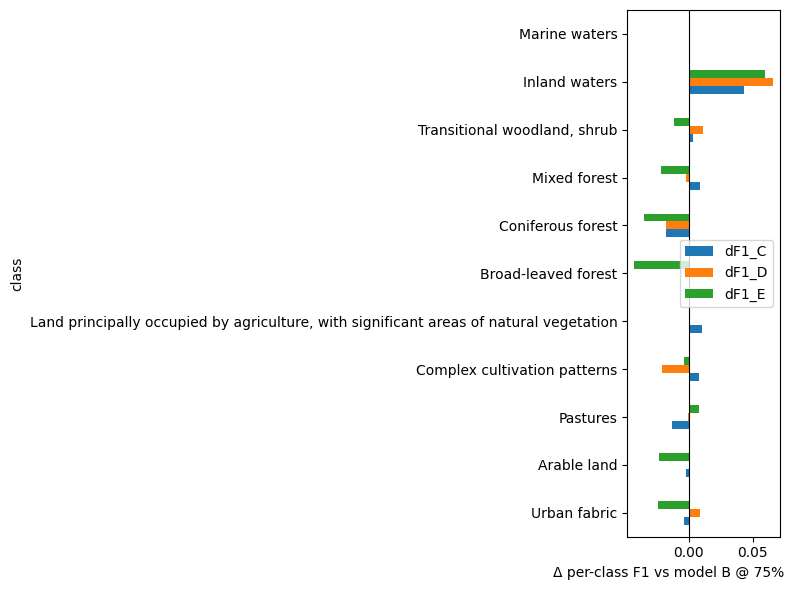

In [23]:
LEVEL75_COV = 0.75
pB = probs_cache[('B: optical (mask-aug)', LEVEL75_COV)]
f1B = f1_score(Y[te], pB >= 0.5, average=None, zero_division=0)
per_class = pd.DataFrame({'class': CLASSES, 'F1_B': f1B.round(3),
                          'test_support': Y[te].sum(0).astype(int)})
for short, name in [('C', 'C: +SAR early fusion'), ('D', 'D: +SAR late fusion'),
                    ('E', 'E: +SAR deep late fusion')]:
    f1x = f1_score(Y[te], probs_cache[(name, LEVEL75_COV)] >= 0.5, average=None, zero_division=0)
    per_class[f'dF1_{short}'] = (f1x - f1B).round(3)
display(per_class.sort_values('dF1_D'))

ax = per_class.set_index('class')[['dF1_C', 'dF1_D', 'dF1_E']].plot.barh(figsize=(8, 6))
ax.set_xlabel('Δ per-class F1 vs model B @ 75% coverage'); ax.axvline(0, color='k', lw=.8)
plt.tight_layout(); plt.savefig(FIG_DIR / 'per_class_delta.png', dpi=120); plt.show()


### Representative successes and failures (75% coverage)

Using the best SAR model at 75% coverage: patches where its full prediction set is exactly
right while B's is wrong (**rescued by SAR**), and patches where both fail.
Shown: masked optical RGB as the models see it (grey = masked), full RGB for reference, SAR VV.


best SAR model @75%: D: +SAR late fusion
exact-match at 75% cover: B 11.1%, D 11.9% | rescued by SAR: 55 | both fail: 1857


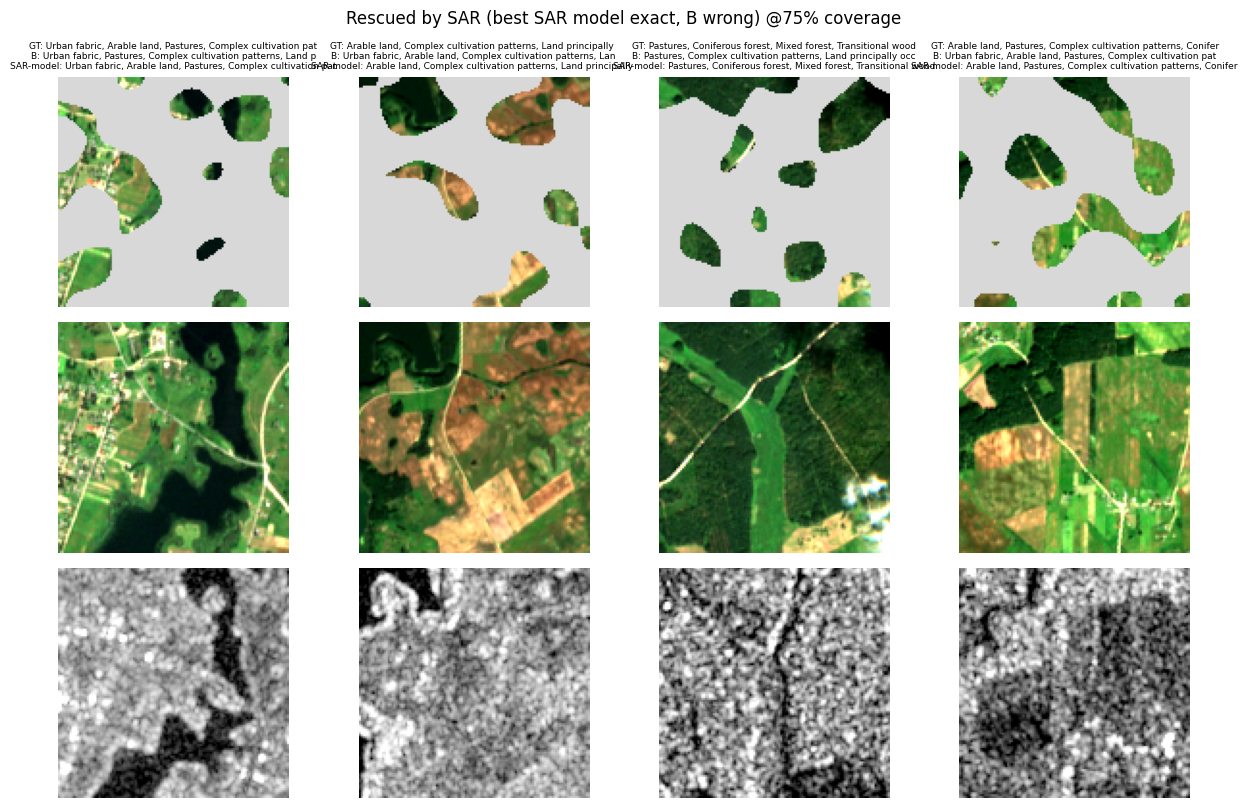

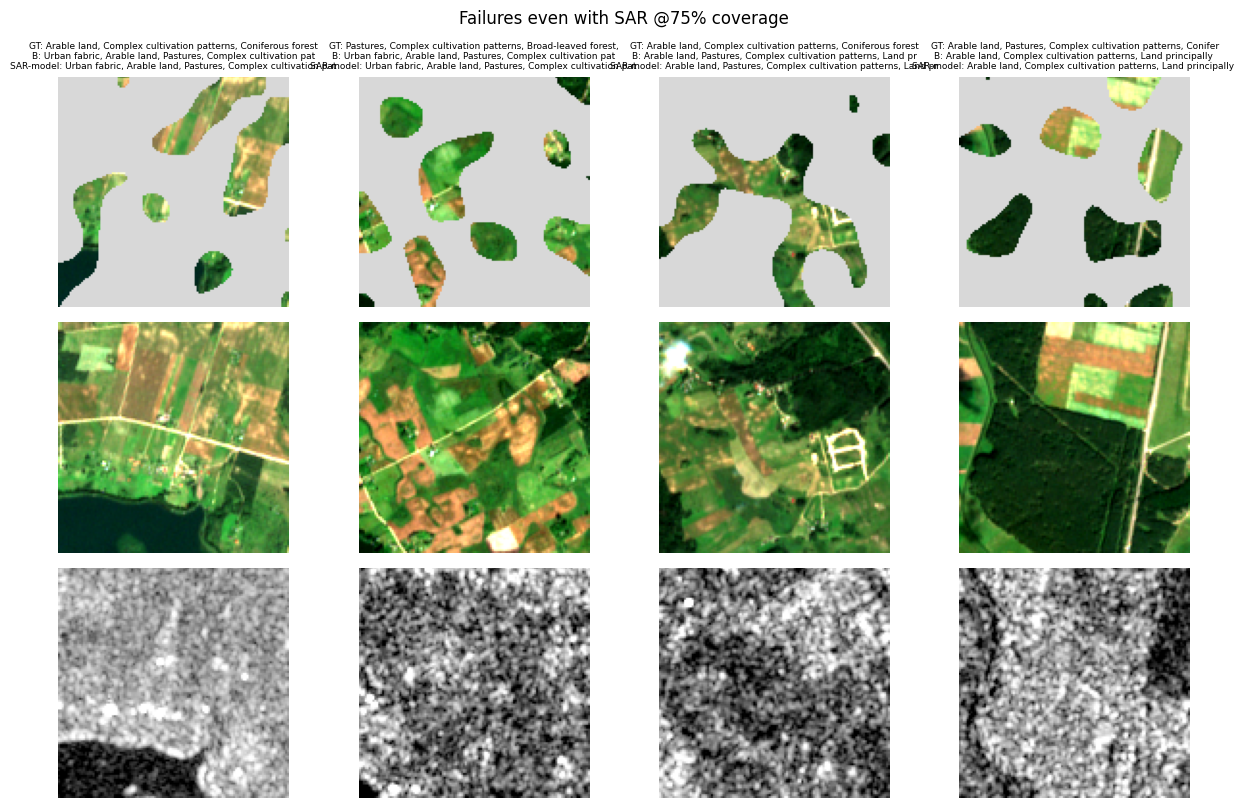

In [24]:
best_sar = res[(res['coverage'] == LEVEL75_COV) & (res['model'] != 'A: optical (clean-trained)')
               & (res['model'] != 'B: optical (mask-aug)')].sort_values('macro_F1').iloc[-1]['model']
print('best SAR model @75%:', best_sar)
pS = probs_cache[(best_sar, LEVEL75_COV)]
yb_hat, ys_hat = pB >= 0.5, pS >= 0.5
yt_b = Y[te].astype(bool)
exactB, exactS = (yb_hat == yt_b).all(1), (ys_hat == yt_b).all(1)
rescued   = np.where(exactS & ~exactB)[0]
both_fail = np.where(~exactS & ~exactB)[0]
print(f'exact-match at 75% cover: B {exactB.mean():.1%}, {best_sar.split(":")[0]} {exactS.mean():.1%} | '
      f'rescued by SAR: {len(rescued)} | both fail: {len(both_fail)}')
LEVEL75 = MASK_LEVELS.index(LEVEL75_COV)

def show_cases(case_ids, title, n=4):
    rng = np.random.default_rng(SEED)
    pick = rng.choice(case_ids, min(n, len(case_ids)), replace=False)
    fig, axes = plt.subplots(3, len(pick), figsize=(3.1 * len(pick), 8.2))
    axes = axes.reshape(3, -1)
    for j, k in enumerate(pick):
        gi = te[k]; m = eval_mask(LEVEL75, gi)
        im = rgb(gi).copy(); im[m] = 0.85
        axes[0, j].imshow(im); axes[1, j].imshow(rgb(gi)); axes[2, j].imshow(sar_img(gi), cmap='gray')
        fmt = lambda v: ', '.join(np.array(CLASSES)[v] if v.any() else ['-'])[:60]
        axes[0, j].set_title(f'GT: {fmt(yt_b[k])}\nB: {fmt(yb_hat[k])}\nSAR-model: {fmt(ys_hat[k])}', fontsize=6.5)
        for ax in axes[:, j]: ax.axis('off')
    for r, lab in enumerate(['masked S2 (model input)', 'clean S2 (reference)', 'S1 VV']):
        axes[r, 0].set_ylabel(lab, fontsize=8)
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(FIG_DIR / f'{title.split()[0].lower()}_cases.png', dpi=120); plt.show()

if len(rescued):   show_cases(rescued, 'Rescued by SAR (best SAR model exact, B wrong) @75% coverage')
if len(both_fail): show_cases(both_fail, 'Failures even with SAR @75% coverage')


## 10. Discussion

### Headline results (test macro-F1, 30 epochs; ± = 95% paired-bootstrap CI on the delta vs B)

| coverage | A: clean-trained | B: mask-aug | C: early fusion | D: late fusion | E: deep late fusion |
|---|---|---|---|---|---|
| 0% | 0.753 | 0.750 | 0.751 | 0.751 | 0.725 (**sig. worse**) |
| 50% | 0.633 | 0.747 | 0.741 | 0.744 | 0.726 (**sig. worse**) |
| 75% | 0.412 | 0.730 | 0.733 | 0.735 | 0.722 (**sig. worse**) |
| 90% | 0.255 | 0.714 | **0.723 (sig.)** | **0.723 (sig.)** | 0.711 |
| 100% | 0.118 | 0.330 | **0.711 (sig.)** | 0.639 (sig.) | 0.601 (sig.) |

**Finding 1 — the clean-trained baseline is brittle.** Model A collapses under masking it never
saw in training (0.753 → 0.41 at 75% coverage): distribution shift, not information loss —
Model B proves the information is still there.

**Finding 2 — mask augmentation alone recovers most of the loss.** Scene-level labels of a
1.2 × 1.2 km patch are spatially redundant: with only 10% of pixels visible, Model B still
reaches 0.714 macro-F1 (vs 0.750 clean). Partial cloud cover leaves little headroom for SAR.

**Finding 3 — bootstrap verdict: SAR's benefit is real, but only at ≥90% coverage.**
With 1,000 paired resamples, no SAR model beats B significantly at 0–75% coverage
(deltas −0.5…+0.5 pts, CIs straddle 0; C's small negative at 50% is borderline and, with 18
simultaneous tests at 95%, consistent with a false positive). At **90%** both C and D show a
small but significant gain (+0.8 pts, CIs exclude 0 — and the agreement between two
independent models strengthens it). At **100%** the effect is decisive: C holds 0.711
(+38.2 pts over B, ~95% of clean performance) while B falls to label-prior guessing.
SAR is *insurance against (near-)total optical loss*, not a booster under partial clouds.

**Finding 4 — architecture: simplest fusion won.** Late fusion (D) matched but did not beat
early fusion; strikingly, at 100% coverage early fusion is much better (0.711 vs 0.639) —
plausibly because C's shared trunk devotes its full capacity to SAR when optical is zeroed,
while during training D's dedicated SAR branch receives weak gradients whenever the head can
lean on visible optical. The deep ResNet model (E, ~14 M params) was **significantly worse
than the 1.9 M-param SimpleCNN at every coverage below 90%**: its validation score peaked at
epoch 8 and declined — classic overfitting of high capacity on 4.2 k training patches. More
capacity is not the bottleneck; data (or pretraining) is.

**Finding 5 — where SAR helps (per-class, 75% coverage).** The only consistent winner across
all three SAR models is **Inland waters** (+4.3 to +6.6 F1) — specular water gives a
distinctively low backscatter that survives any optical mask. Small consistent losses on
Coniferous forest (−1.8 to −3.5): C-band VV/VH separates vegetation types poorly. Marine
waters sits at F1 = 1.0 for every model at every level — an easy class that inflates macro
averages. At 75% coverage the best SAR model (D) exactly matches the full label set on 11.9%
of patches vs B's 11.1% (55 rescued); 1,857 patches fail under both — dominated by
fine-grained agriculture/forest confusions where the scene-level CORINE labels are ambiguous
even in clean imagery.

**Remaining uncertainty.** Bootstrap CIs cover test-set sampling noise only. Training-seed
variance (observed at 1–2 pts between the 14- and 30-epoch runs) is not yet quantified — the
90%-coverage gains (+0.8 pts) should be confirmed with seed replicates before being relied on;
the 100%-coverage and Model-E conclusions are far outside any plausible noise band.

### Threats to validity we controlled for
- **Paired evaluation**: identical deterministic masks per patch across all models and levels;
  bootstrap deltas computed on shared resamples (paired).
- **No leakage**: official reBEN splits; normalisation stats from train only; no threshold tuning.
- **Fair comparisons**: same training regime, seed, and loss for every model.

### Known limitations
- Simulated masks (value = band mean) approximate *thick* clouds; thin cloud, haze and cloud
  shadows corrupt rather than remove signal — a harder, more realistic setting.
- Scene-level noisy labels (CORINE-derived); single country/season subset limits generality.
- No explicit mask channel: models must infer what is missing.
- 18 simultaneous significance tests at 95% imply ~1 expected false positive; we only trust
  effects that are consistent across models/levels.

### What I would try next
1. **Seed replicates** (×3) for B, C, D to confirm the 90%-coverage SAR gain.
2. **Mask as an explicit input channel** — the remaining cheap idea for the mid-coverage regime.
3. **Pretrained remote-sensing backbones** (SSL4EO / BigEarthNet-pretrained) — the right way to
   spend capacity, given Finding 4; likely lifts all conditions and may widen the SAR gap.
4. **Cross-modal distillation**: regress SAR features onto clean-optical features so the SAR
   branch learns optical-like semantics for the fully-clouded case (targets Finding 4's
   late-fusion weakness at 100%).
5. **Real cloud degradation** (overlay actually-cloudy Sentinel-2 acquisitions) instead of blobs.
6. Scale to the full 19-class reBEN dataset across countries/seasons.
